# SYDE 556/750 &mdash; Practice Notebook 1
## Neurons &amp; Population Representation

**Prepares you for: Test 1.**

This notebook is **ungraded practice**. Working through it is how you study for Test 1 &mdash; a 20-minute, closed-book, pen-and-paper test that draws directly on the skills you build here.

**How to use it**
- **No solutions are released.** Each part ends with an *Expected result* checkpoint so you can tell whether you are on track.
- Cells marked &#x270D; are for written answers.

**Contents**
1. Representation of scalars &mdash; encoding &amp; decoding, sources of error, LIF neurons
2. Representation of vectors &mdash; 2D tuning curves, vector populations


In [53]:
import numpy as np
import matplotlib.pyplot as plt
import math


# A fixed seed makes your tuning curves reproducible. Computing decoders
# without regularization can hit numerical issues for some random draws;
# a fixed seed lets you reliably pick a well-behaved population.
rng = np.random.default_rng(556)


# 1. Representation of Scalars

## 1.1 Basic encoding and decoding

Represent a scalar $x \in [-1, 1]$ with a population of neurons. Start with a **rectified linear (ReLU)** neuron model,
$$a = G[J] = \max(J, 0).$$

For each neuron, draw:
- a maximum firing rate $a^{\max}$ uniformly from $[100, 200]$ Hz (the rate at $x = 1$),
- an $x$-intercept $\xi$ uniformly from $[-0.95, 0.95]$,
- an encoder $e \in \{+1, -1\}$ (each equally likely).

The input current is $J = \alpha \, \langle x, e \rangle + J^{\mathrm{bias}}$, where $\alpha$ is the gain and $J^{\mathrm{bias}}$ the bias.


**a) Computing gain and bias.** For a general model $a = G[J]$ (assuming the inverse $J = G^{-1}[a]$ exists), solve
$$a^{\max} = G[\alpha + J^{\mathrm{bias}}], \qquad 0 = G[\alpha\,\xi + J^{\mathrm{bias}}]$$
for the gain $\alpha$ and bias $J^{\mathrm{bias}}$. Then simplify for the ReLU case $G[J] = \max(J, 0)$.

&#x1F4CC; The $x$-intercept $\xi$ is the value of $\langle x, e\rangle$ at which the neuron just begins to fire. Formally the threshold current is $J_{\mathrm{th}} = \lim_{\varepsilon \to 0} G^{-1}[\varepsilon]$; use $J_{\mathrm{th}}$ in place of the ill-defined $G^{-1}[0]$. The nonlinearity should not appear in the expression for the gain or bias. For the ReLU, $J_{\mathrm{th}} = 0$.


&#x270D; *Your derivation here.* (Write the general solution for $\alpha$ and $J^{\mathrm{bias}}$, then the simplified ReLU expressions. You will reuse these in the code below and on Test 1.)

**b) Neuron tuning curves.** Plot the tuning curves $a_i(x)$ for **16** randomly generated neurons following the distributions above.

&#x1F4CC; Sample $x \in [-1, 1]$ with $\Delta x = 0.05$ (41 points). Use this same sampling throughout the section.
&#x1F4D6; Compare with Figure 2.4 in the book (different model / rate range).


Text(0, 0.5, 'firing rate (Hz)')

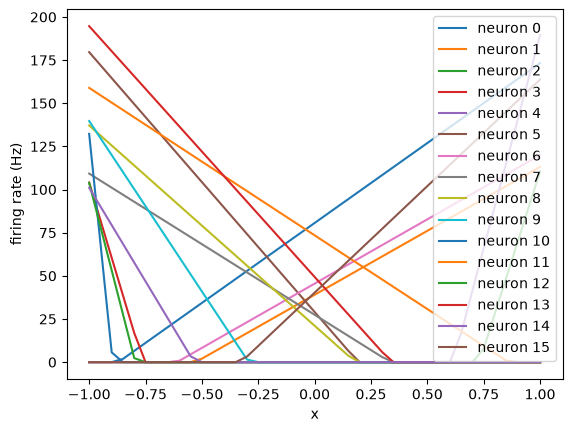

In [54]:
def G_relu(J):
    return np.maximum(0, J)
    

def gain_bias_relu(a_max, xi):
    # Return (alpha, J_bias) for a ReLU neuron with max rate a_max (at x=1)
    # and x-intercept xi. Use your answer to 1.1(a).
    alpha = a_max / (1 - xi)
    J_bias = (-a_max * xi) / (1-xi)
    return (alpha, J_bias)


n = 16
x = np.arange(-1, 1 + 0.05, 0.05)   # 41 sample points

# TODO: draw a_max, xi, e for n neurons; compute (alpha, J_bias);
#       evaluate a_i(x); plot all 16 curves.

a_max = rng.uniform(100, 200, size=n)
xi = rng.uniform(-0.95, 0.95, size=n)
e = rng.choice([-1,1], size=n)
A = np.zeros((n, len(x)))
for i in range(n):
    alpha, J_bias = gain_bias_relu(a_max[i], xi[i])
    J_i = alpha * e[i] * x + J_bias
    A[i] = G_relu(J_i)

# plt.plot(x, A.T)
for i in range(n):
    plt.plot(x, A[i], label=f"neuron {i}")

plt.legend()
plt.xlabel("x")
plt.ylabel("firing rate (Hz)")


*Expected:* 16 roughly linear curves. Positive-encoder neurons ramp up toward $x = +1$, negative-encoder neurons toward $x = -1$; each reaches its own $a^{\max}$ (somewhere in 100&ndash;200 Hz) at the $\pm 1$ edge, and each turns on at its $x$-intercept.

**c) Computing identity decoders.** Compute the optimal identity decoder $\mathbf{d}$ for those 16 neurons, using the matrix form from class, with **no regularization**. Report the individual decoder coefficients. Let $A$ be the activity matrix (the data from part b).

&#x1F4CC; Without regularization the matrix inversion can throw warnings for unlucky draws; a fixed seed avoids this.


In [55]:
# Build A (neurons x samples). Solve for d via the normal equations
# with no regularization. Report d.
D = np.linalg.inv(A @ A.T) @ A @ x.T


*Expected:* a length-16 vector of decoder weights (mixed signs, individual magnitudes of order $10^{-3}$ to $10^{-4}$).

**d) Evaluating decoding error.** Compute and plot $\hat{x} = \sum_i d_i\, a_i(x)$, overlaying the line $y = x$. In a separate plot show the error $x - \hat{x}$. Report the RMSE.

&#x1F4D6; Compare with Figure 2.7 in the book.


RMSE: 0.0023724614960566465


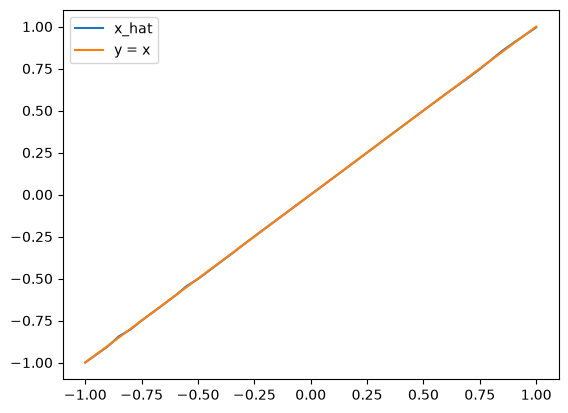

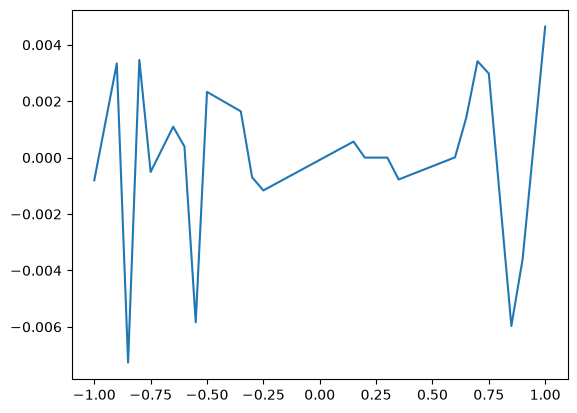

In [56]:
# Compute x_hat; plot x_hat vs x with y=x overlaid; plot (x - x_hat); report RMSE.
x_hat = D @ A

plt.plot(x, x_hat, label="x_hat")
plt.plot(x, x, label="y = x")
plt.legend()
plt.figure()
plt.plot(x, x - x_hat)



rmse = np.sqrt(np.mean((x - x_hat) ** 2))
print(f"RMSE: {rmse}")



*Expected:* $\hat{x}$ tracks $x$ closely; the error wiggles around zero with small amplitude; RMSE on the order of a few percent.

**e) Decoding under noise.** Add zero-mean Gaussian noise to $A$ and decode again. The noise has standard deviation $\sigma = 0.2 \max(A)$ (where $\max(A)$ is the largest firing rate in the population). Resample the noise for every $x$ and every neuron. Reproduce the part-(d) plots and report the RMSE.


RMSE: 0.8386291486364382


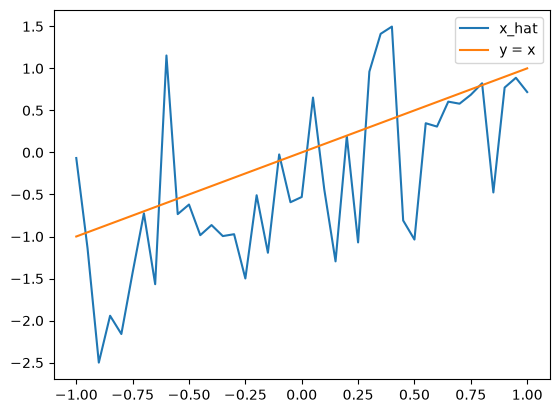

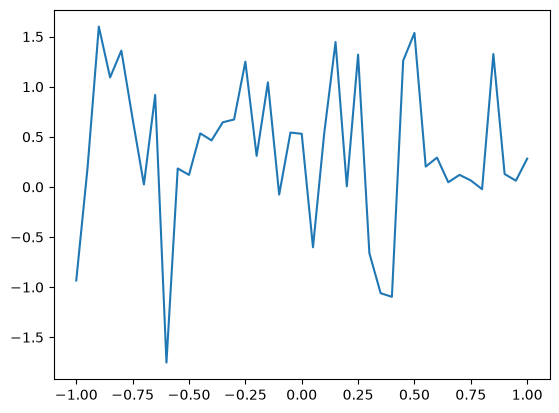

In [57]:
# Compute A_noisy; decode with the SAME d from (c).
# D = np.linalg.inv(A @ A.T) @ A @ x.T
# max_A = A.max()
sigma = 0.2 * A.max()
A_noisy = A + rng.normal(0.0, sigma, size=A.shape)
x_hat = D @ A_noisy

plt.plot(x, x_hat, label="x_hat")
plt.plot(x, x, label="y = x")
plt.legend()
plt.figure()
plt.plot(x, x - x_hat)



rmse = np.sqrt(np.mean((x - x_hat) ** 2))
print(f"RMSE: {rmse}")


*Expected:* visibly noisier $\hat{x}$ and a substantially larger RMSE than in (d).

**f) Accounting for noise in the decoders.** Recompute $\mathbf{d}$ taking noise into account (add the appropriate regularization term, as shown in class). Show how these decoders behave decoding **with** and **without** noise added to $A$, reproducing the (d)-style plots. Report the RMSE for each case.

&#x1F4CC; Use $\sigma = 0.2\max(A)$. **Do not** add noise to the $A$ used to *compute* the decoders &mdash; account for noise via regularization, and use a separately noised $A$ only to *test*.


RMSE clean: 0.04871082998372242
RMSE noisy: 0.17685667284236398


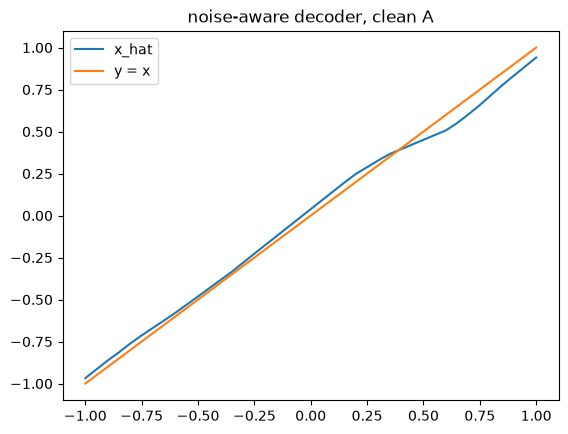

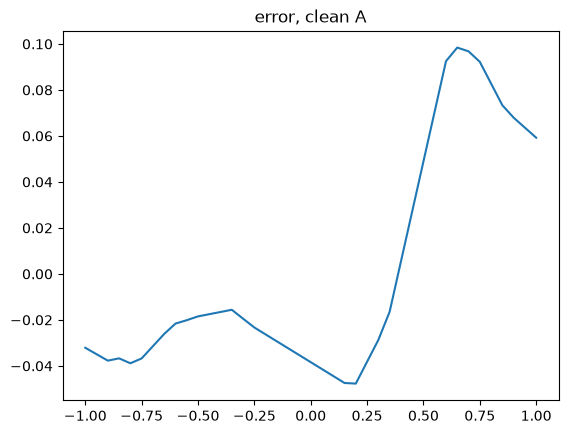

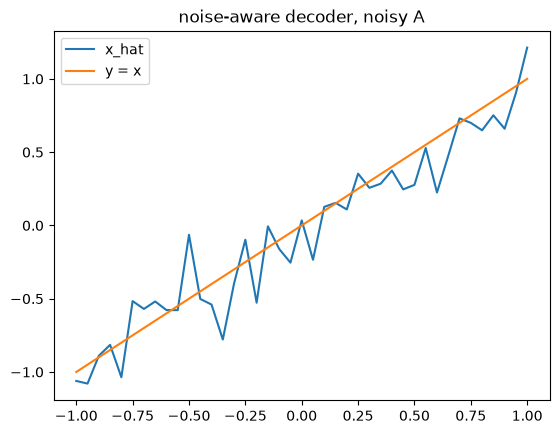

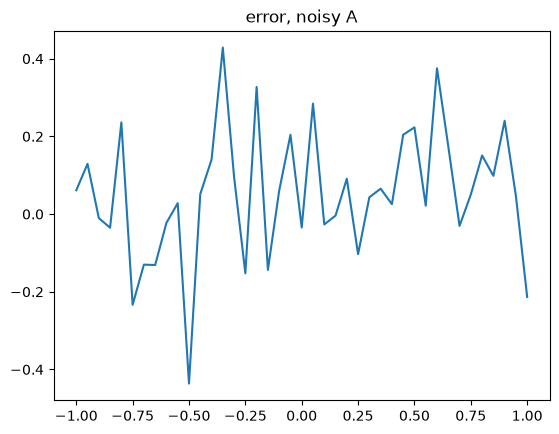

In [58]:
# Regularized decoders.
# Then test on clean A and on noisy A; report both RMSEs.

sigma = 0.2 * A.max()
ai_noisy = A + rng.normal(0.0, sigma, size=A.shape)
n_neurons, N = A.shape
d_reg = np.linalg.lstsq(A @ A.T + N * sigma**2 * np.eye(n_neurons), A @ x.T, rcond=None)[0]

x_hat_clean = d_reg @ A
x_hat_noisy = d_reg @ ai_noisy

plt.figure()
plt.plot(x, x_hat_clean, label="x_hat")
plt.plot(x, x, label="y = x")
plt.legend()
plt.title("noise-aware decoder, clean A")

plt.figure()
plt.plot(x, x - x_hat_clean)
plt.title("error, clean A")

plt.figure()
plt.plot(x, x_hat_noisy, label="x_hat")
plt.plot(x, x, label="y = x")
plt.legend()
plt.title("noise-aware decoder, noisy A")

plt.figure()
plt.plot(x, x - x_hat_noisy)
plt.title("error, noisy A")

rmse_clean = np.sqrt(np.mean((x - x_hat_clean) ** 2))
rmse_noisy = np.sqrt(np.mean((x - x_hat_noisy) ** 2))
print(f"RMSE clean: {rmse_clean}")
print(f"RMSE noisy: {rmse_noisy}")

**g) Interpretation.** Build a 2&times;2 table of the four RMSE values from (d), (e), and (f): rows = decoder type (noise-ignored vs noise-aware), columns = test condition (no noise vs noise added). Comment on what the table shows: what does adding noise to the activities do to the error, and why does accounting for noise when computing the decoders increase / decrease / not change the measured RMSE?


&#x270D; *Your 2&times;2 table and interpretation here.*

*Expected:* the noise-aware decoders barely change the no-noise error but markedly reduce the with-noise error &mdash; regularization trades a tiny bit of clean-case accuracy for robustness.

|  | no noise | noise added |
|---|---:|---:|
| noise-ignored | 0.00237 | 0.984 |
| noise-aware | 0.0119 | 0.165 |


noise-aware performs better on noise added, but worse when the input is clean. The tradeoff is a 0.00953 decrwase RMSE for the clean input is 0.00953, while carrying an improvement of 0.819 RMSE for the noisy case

## 1.2 Exploring sources of error

Use your code from 1.1 to examine the two sources of representation error as the population size $n$ grows.


**a) Distortion vs. noise error.** Plot the error due to **distortion** $E_{\mathrm{dist}}$ and the error due to **noise** $E_{\mathrm{noise}}$ as functions of $n$. Make two log-log plots (one per error type) for at least $n \in [4, 8, 16, 32, 64, 128, 256, 512]$. For each $n$, average over at least 5 runs (fresh $\alpha$, $J^{\mathrm{bias}}$, $e$ each run). Compute $\mathbf{d}$ accounting for noise with $\sigma = 0.1\max(A)$. Show visually whether each error scales like $1/n$ or $1/n^2$.

&#x1F4D6; See Equation 2.9 and Figure 2.6 in the book.


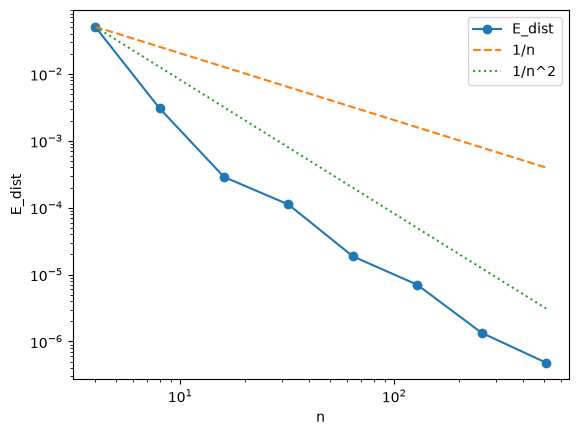

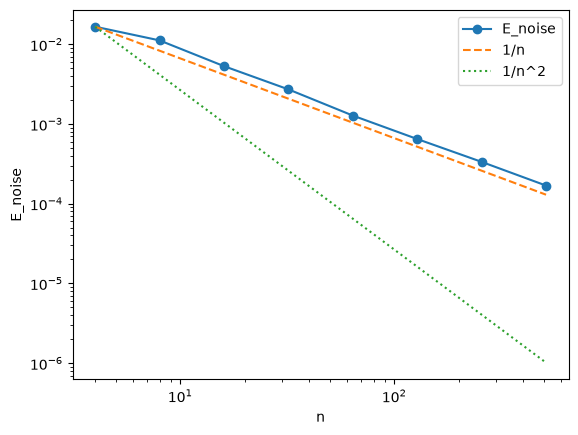

In [59]:
ns = np.array([4, 8, 16, 32, 64, 128, 256, 512])
n_runs = 5
E_dist_avg = []
E_noise_avg = []


for n in ns:
    dist_runs = []
    noise_runs = []
    for _ in range(n_runs):


        a_max = rng.uniform(100, 200, size=n)
        xi = rng.uniform(-0.95, 0.95, size=n)
        e = rng.choice([-1,1], size=n)
        A = np.zeros((n, len(x)))
        for i in range(n):
            alpha, J_bias = gain_bias_relu(a_max[i], xi[i])
            J_i = alpha * e[i] * x + J_bias
            A[i] = G_relu(J_i)

        sigma = 0.1 * A.max()
        ai_noisy = A + rng.normal(0.0, sigma, size=A.shape)
        n_neurons, N = A.shape
        d_noisy = np.linalg.lstsq(A @ A.T + N * sigma**2 * np.eye(n), A @ x.T, rcond=None)[0]
        x_hat_noisy = d_noisy @ A
        dist_runs.append(np.mean((x-x_hat_noisy) ** 2))
        noise_runs.append(sigma**2 * np.sum(d_noisy**2))
    E_dist_avg.append(np.mean(dist_runs))
    E_noise_avg.append(np.mean(noise_runs))

E_dist_avg = np.array(E_dist_avg)
E_noise_avg = np.array(E_noise_avg)

# reference lines pinned to the first point, so only the slope matters
ref_1 = E_dist_avg[0] * (ns[0] / ns)
ref_2 = E_dist_avg[0] * (ns[0] / ns) ** 2
plt.figure()
plt.loglog(ns, E_dist_avg, "o-", label="E_dist")
plt.loglog(ns, ref_1, "--", label="1/n")
plt.loglog(ns, ref_2, ":", label="1/n^2")
plt.xlabel("n")
plt.ylabel("E_dist")
plt.legend()
ref_1 = E_noise_avg[0] * (ns[0] / ns)
ref_2 = E_noise_avg[0] * (ns[0] / ns) ** 2
plt.figure()
plt.loglog(ns, E_noise_avg, "o-", label="E_noise")
plt.loglog(ns, ref_1, "--", label="1/n")
plt.loglog(ns, ref_2, ":", label="1/n^2")
plt.xlabel("n")
plt.ylabel("E_noise")
plt.legend()




    


# For each n: average over >=5 runs.
#   E_dist  : mean squared (x - x_hat) with NO noise added
#   E_noise : the noise-induced term (sigma^2 * sum d_i^2)
# Plot each vs n on log-log axes; overlay reference slopes 1/n and 1/n^2.
# TODO


*Expected:* on log-log axes, $E_{\mathrm{dist}}$ falls roughly as $1/n^2$ (steeper line) and $E_{\mathrm{noise}}$ roughly as $1/n$ (shallower line).

**b) Lower noise level.** Repeat part (a) with $\sigma = 0.01\max(A)$.

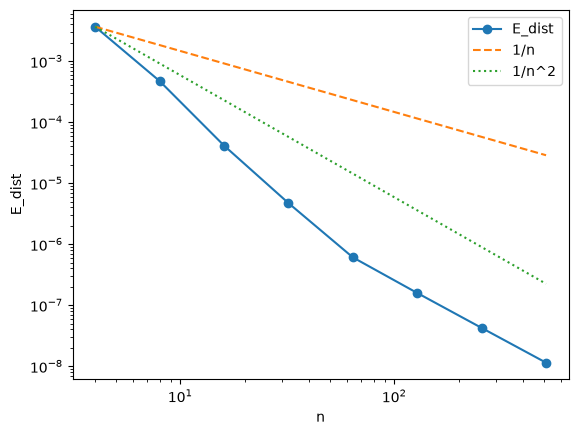

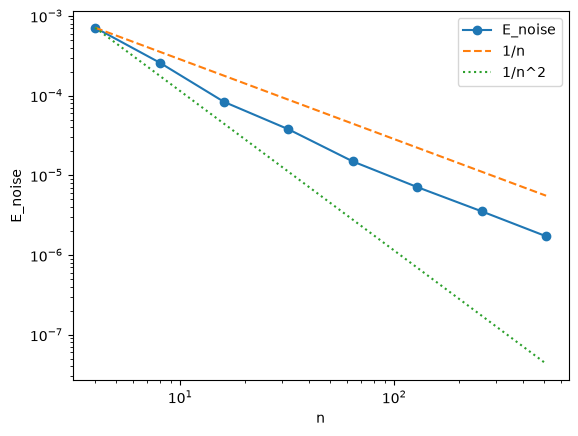

In [60]:
# Same as 1.2(a) with sigma = 0.01 * max(A).
ns = np.array([4, 8, 16, 32, 64, 128, 256, 512])
n_runs = 5
E_dist_avg = []
E_noise_avg = []


for n in ns:
    dist_runs = []
    noise_runs = []
    for _ in range(n_runs):


        a_max = rng.uniform(100, 200, size=n)
        xi = rng.uniform(-0.95, 0.95, size=n)
        e = rng.choice([-1,1], size=n)
        A = np.zeros((n, len(x)))
        for i in range(n):
            alpha, J_bias = gain_bias_relu(a_max[i], xi[i])
            J_i = alpha * e[i] * x + J_bias
            A[i] = G_relu(J_i)

        sigma = 0.01 * A.max()
        ai_noisy = A + rng.normal(0.0, sigma, size=A.shape)
        n_neurons, N = A.shape
        d_noisy = np.linalg.lstsq(A @ A.T + N * sigma**2 * np.eye(n), A @ x.T, rcond=None)[0]
        x_hat_noisy = d_noisy @ A
        dist_runs.append(np.mean((x-x_hat_noisy) ** 2))
        noise_runs.append(sigma**2 * np.sum(d_noisy**2))
    E_dist_avg.append(np.mean(dist_runs))
    E_noise_avg.append(np.mean(noise_runs))

E_dist_avg = np.array(E_dist_avg)
E_noise_avg = np.array(E_noise_avg)

# reference lines pinned to the first point, so only the slope matters
ref_1 = E_dist_avg[0] * (ns[0] / ns)
ref_2 = E_dist_avg[0] * (ns[0] / ns) ** 2
plt.figure()
plt.loglog(ns, E_dist_avg, "o-", label="E_dist")
plt.loglog(ns, ref_1, "--", label="1/n")
plt.loglog(ns, ref_2, ":", label="1/n^2")
plt.xlabel("n")
plt.ylabel("E_dist")
plt.legend()
ref_1 = E_noise_avg[0] * (ns[0] / ns)
ref_2 = E_noise_avg[0] * (ns[0] / ns) ** 2
plt.figure()
plt.loglog(ns, E_noise_avg, "o-", label="E_noise")
plt.loglog(ns, ref_1, "--", label="1/n")
plt.loglog(ns, ref_2, ":", label="1/n^2")
plt.xlabel("n")
plt.ylabel("E_noise")
plt.legend()

**c) Interpretation.** What does the difference between the graphs in (a) and (b) tell us about the sources of error in neural populations?

As noise decreases, error due to noise is less relevant compared to distortion error

## 1.3 Leaky Integrate-and-Fire (LIF) neurons

Switch to the **rate approximation of the LIF** neuron:
$$G[J] = \begin{cases} \dfrac{1}{\tau_{\mathrm{ref}} - \tau_{\mathrm{RC}} \ln\!\left(1 - \frac{1}{J}\right)} & J > 1 \\[2mm] 0 & \text{otherwise.}\end{cases}$$
Use $\tau_{\mathrm{ref}} = 2$ ms and $\tau_{\mathrm{RC}} = 20$ ms throughout.


**a) Computing gain and bias.** As in 1.1(a), given a maximum firing rate $a^{\max}$ and an $x$-intercept $\xi$, write down the equations for $\alpha$ and $J^{\mathrm{bias}}$ for this LIF rate model.

&#x270D; *Your derivation here.*
For the LIF rate model, $J_{\mathrm{th}} = 1$. Inverting $a^{\max} = G[J^{\max}]$ gives

$$
J^{\max} = \frac{1}{1 - \exp\!\left(\dfrac{a^{\max}\,\tau_{\mathrm{ref}} - 1}{a^{\max}\,\tau_{\mathrm{RC}}}\right)}.
$$

The two encoding conditions are $J^{\max} = \alpha + J^{\mathrm{bias}}$ and $1 = \alpha\,\xi + J^{\mathrm{bias}}$, so

$$
J^{\mathrm{bias}} = \frac{\xi\, J^{\max} - 1}{\xi - 1}, \qquad
\alpha = \frac{1 - J^{\mathrm{bias}}}{\xi} = \frac{J^{\max} - 1}{1 - \xi}.
$$

**b) Tuning curves.** Generate the same kind of plot as in 1.1(b) for 16 LIF neurons. Use the same distributions of $x$-intercepts ($[-0.95, 0.95]$), maximum rates ($[100, 200]$ Hz), and encoders ($\pm 1$).


Text(0, 0.5, 'firing rate (Hz)')

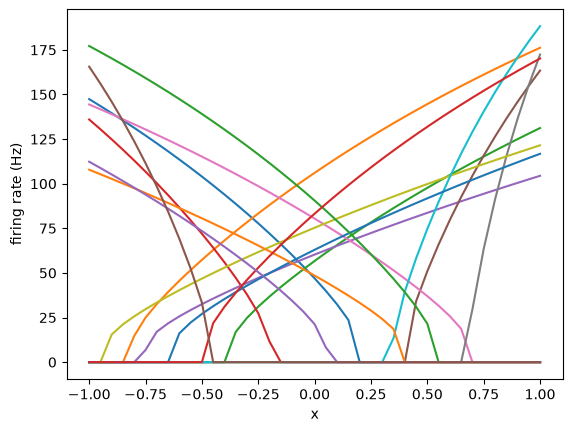

In [62]:
def lif_rate(J, tau_ref=0.002, tau_rc=0.020):
    J = np.asarray(J, dtype=float)
    a = np.zeros_like(J)
    firing = J > 1
    a[firing] = 1.0 / (tau_ref - tau_rc * np.log(1.0 - 1.0 / J[firing]))
    return a

def gain_bias_lif(a_max, xi, tau_ref=0.002, tau_rc=0.020):
    # Return (alpha, J_bias) for a LIF neuron. Use your answer to 1.3(a).
    J_max = 1/(1 - math.exp((a_max*tau_ref - 1)/(a_max*tau_rc)))
    J_bias = (xi*J_max - 1) / (xi-1)
    alpha = (J_max - 1) / (1 - xi)

    return (alpha, J_bias)

# Generate and plot 16 LIF tuning curves over x in [-1, 1], dx = 0.05.
n = 16
a_max = rng.uniform(100, 200, size=n)
xi = rng.uniform(-0.95, 0.95, size=n)
e = rng.choice([-1.0, 1.0], size=n)

A = np.zeros((n, len(x)))
for i in range(n):
    alpha, J_bias = gain_bias_lif(a_max[i], xi[i])
    J_i = alpha * e[i] * x + J_bias
    A[i] = lif_rate(J_i)
    plt.plot(x, A[i])

plt.xlabel("x")
plt.ylabel("firing rate (Hz)")

*Expected:* curves with the characteristic LIF concave-up bend just above threshold, saturating toward $a^{\max}$ at the $\pm 1$ edge.

**c) Impact of noise (trimmed).** Repeat the noise analysis of 1.1, but only for the **noise-aware decoders**. Report the full 2&times;2 RMSE table (as in 1.1g), but you only need to **plot four panels**: $\hat{x}$ and the error $x - \hat{x}$ for the noise-aware decoder, tested (i) without and (ii) with noise added. Use $\sigma = 0.2\max(A)$.


RMSE clean: 0.032348427898601706
RMSE noisy: 0.12089762395987896


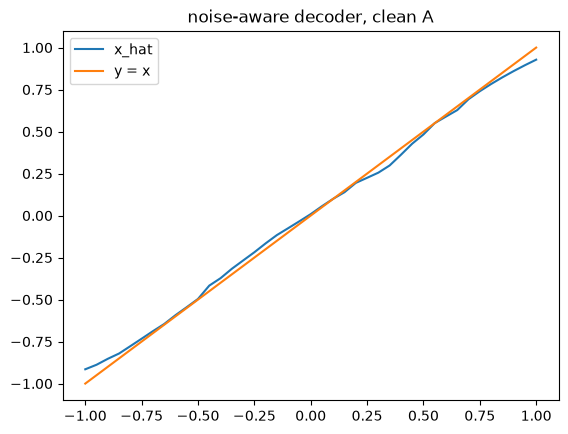

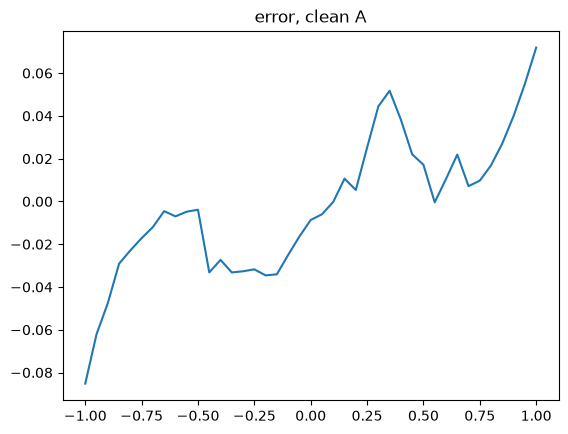

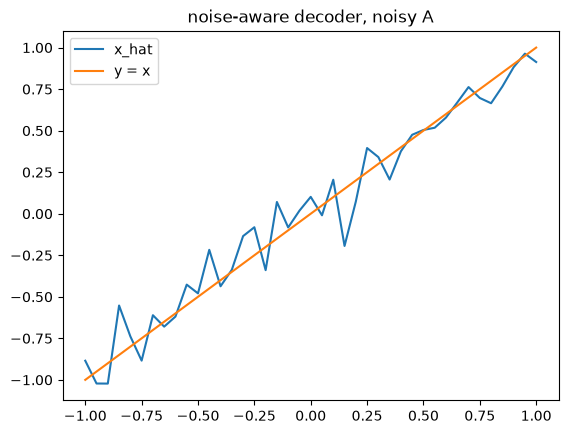

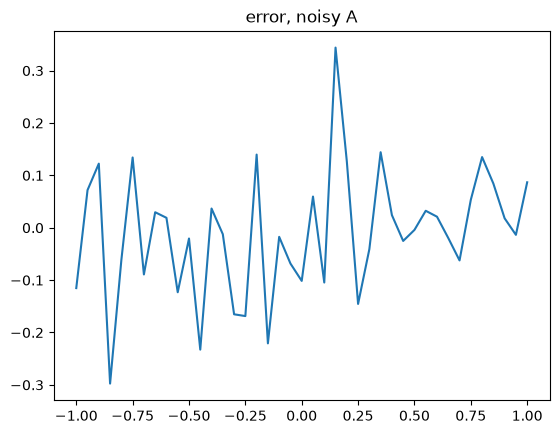

In [63]:
# Compute noise-aware LIF decoders; test on clean and noisy A.
# Plot 4 panels (x_hat & error, for clean-test and noisy-test); report the 2x2 RMSE table.
# Regularized decoders.
# Then test on clean A and on noisy A; report both RMSEs.

sigma = 0.2 * A.max()
ai_noisy = A + rng.normal(0.0, sigma, size=A.shape)
n_neurons, N = A.shape
d_reg = np.linalg.lstsq(A @ A.T + N * sigma**2 * np.eye(n_neurons), A @ x.T, rcond=None)[0]

x_hat_clean = d_reg @ A
x_hat_noisy = d_reg @ ai_noisy

plt.figure()
plt.plot(x, x_hat_clean, label="x_hat")
plt.plot(x, x, label="y = x")
plt.legend()
plt.title("noise-aware decoder, clean A")

plt.figure()
plt.plot(x, x - x_hat_clean)
plt.title("error, clean A")

plt.figure()
plt.plot(x, x_hat_noisy, label="x_hat")
plt.plot(x, x, label="y = x")
plt.legend()
plt.title("noise-aware decoder, noisy A")

plt.figure()
plt.plot(x, x - x_hat_noisy)
plt.title("error, noisy A")

rmse_clean = np.sqrt(np.mean((x - x_hat_clean) ** 2))
rmse_noisy = np.sqrt(np.mean((x - x_hat_noisy) ** 2))
print(f"RMSE clean: {rmse_clean}")
print(f"RMSE noisy: {rmse_noisy}")

# 2. Representation of Vectors

## 2.1 Vector tuning curves

Let the neurons represent a 2D vector $\vec{x}$. The current is $J = \alpha\,\langle \vec{e}, \vec{x}\rangle + J^{\mathrm{bias}}$, where both $\vec{e}$ and $\vec{x}$ are 2D. Keep $\tau_{\mathrm{ref}} = 2$ ms, $\tau_{\mathrm{RC}} = 20$ ms.


**a) 2D tuning curve.** Plot the tuning curve of a LIF neuron whose preferred-direction vector $\vec{e}$ is at angle $\theta = -\pi/4$, with an $x$-intercept at the origin and a maximum firing rate of 100 Hz (the rate when $\vec{x} = \vec{e}$).

&#x1F40D; For 3D surface plots, see the matplotlib `mplot3d` tutorial.
&#x1F4D6; Similar to Figure 2.8a in the book.


Text(0.5, 0, 'firing rate (Hz)')

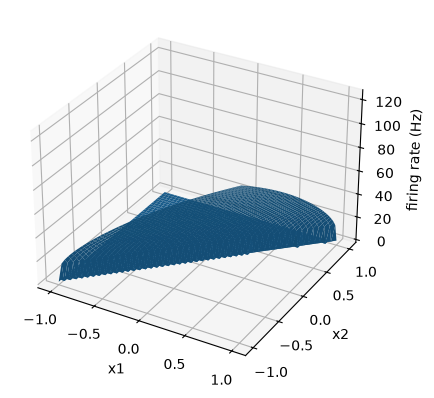

In [64]:
'''
def lif_rate(J, tau_ref=0.002, tau_rc=0.020):
    J = np.asarray(J, dtype=float)
    a = np.zeros_like(J)
    firing = J > 1
    a[firing] = 1.0 / (tau_ref - tau_rc * np.log(1.0 - 1.0 / J[firing]))
    return a

def gain_bias_lif(a_max, xi, tau_ref=0.002, tau_rc=0.020):
    # Return (alpha, J_bias) for a LIF neuron. Use your answer to 1.3(a).
    J_max = 1/(1 - math.exp((a_max*tau_ref - 1)/(a_max*tau_rc)))
    J_bias = (xi*J_max - 1) / (xi-1)
    alpha = (J_max - 1) / (1 - xi)

    return (alpha, J_bias)
'''

# Surface plot of a(x1, x2) over the 2D input plane for the described neuron.
alpha, J_bias = gain_bias_lif(100, 0)
theta = -np.pi / 4
e = np.array([np.cos(theta), np.sin(theta)])

x1 = np.linspace(-1, 1, 50)
x2 = np.linspace(-1, 1, 50)
X1, X2 = np.meshgrid(x1, x2)

J = alpha * (e[0]*X1 + e[1]*X2) + J_bias

G = lif_rate(J)


fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.plot_surface(X1, X2, G)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("firing rate (Hz)")



**b) Tuning curve around the unit circle.** For the same neuron, plot the firing rate as a function of angle $\theta$ for $\vec{x}$ on the unit circle. Fit a curve of the form $c_1 \cos(c_2\theta + c_3) + c_4$ and overlay it.

&#x1F40D; Use `scipy.optimize.curve_fit`.
&#x1F4D6; Similar to Figure 2.8b in the book.


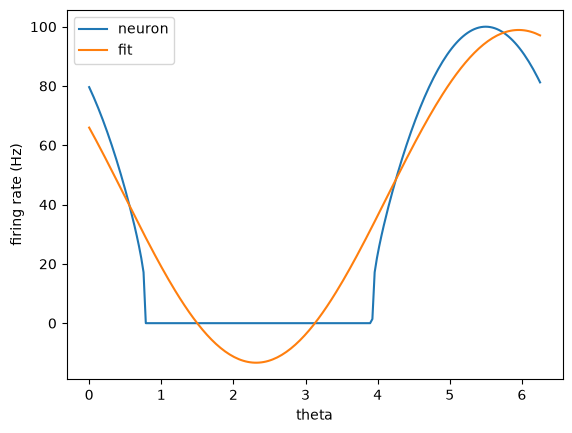

In [66]:
# Sample theta in [0, 2*pi); evaluate the neuron's rate for x = [cos t, sin t];
# fit c1*cos(c2*theta + c3) + c4 and overlay.

'''
def lif_rate(J, tau_ref=0.002, tau_rc=0.020):
    J = np.asarray(J, dtype=float)
    a = np.zeros_like(J)
    firing = J > 1
    a[firing] = 1.0 / (tau_ref - tau_rc * np.log(1.0 - 1.0 / J[firing]))
    return a

def gain_bias_lif(a_max, xi, tau_ref=0.002, tau_rc=0.020):
    # Return (alpha, J_bias) for a LIF neuron. Use your answer to 1.3(a).
    J_max = 1/(1 - math.exp((a_max*tau_ref - 1)/(a_max*tau_rc)))
    J_bias = (xi*J_max - 1) / (xi-1)
    alpha = (J_max - 1) / (1 - xi)

    return (alpha, J_bias)
'''
from scipy.optimize import curve_fit

# Surface plot of a(x1, x2) over the 2D input plane for the described neuron.
theta = np.linspace(0, 2*np.pi, 200, endpoint=False)
x1 = np.cos(theta)
x2 = np.sin(theta)

alpha, J_bias = gain_bias_lif(100, 0)
e = np.array([np.cos(-np.pi/4), np.sin(-np.pi/4)])

J = alpha * (e[0]*x1 + e[1]*x2) + J_bias
a = lif_rate(J)

def cosine(theta, c1, c2, c3, c4):
    return c1*np.cos(c2*theta + c3) + c4

popt, _ = curve_fit(cosine, theta, a)

plt.plot(theta, a, label="neuron")
plt.plot(theta, cosine(theta, *popt), label="fit")
plt.xlabel("theta")
plt.ylabel("firing rate (Hz)")
plt.legend()



**c) Discussion.** What makes a cosine a good fit here, and why does the actual tuning curve differ from the ideal cosine?

&#x270D; *Your answer here.*

actual one has the threshold before activation, which makes it non-smooth (unlike cosine). Cosine is a good fit since the neuron is a cosine with a threshold + scale + shift. 


## 2.2 Vector representation

**a) Encoders.** Generate 100 random unit vectors uniformly distributed around the unit circle &mdash; these are the encoders $\vec{e}$ for 100 neurons. Plot them with a quiver/line plot (arrows, not just points).


(np.float64(-0.05500000000000001),
 np.float64(0.05500000000000001),
 np.float64(-0.05500000000000001),
 np.float64(0.05500000000000001))

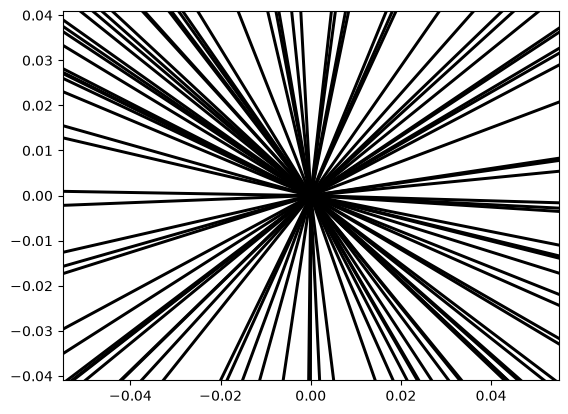

In [72]:
# Generate 100 unit-vector encoders uniformly on the circle; quiver-plot them.
theta = rng.uniform(0, 2*np.pi, size=100)
ex = np.cos(theta)
ey = np.sin(theta)

plt.quiver(
    np.zeros(100), np.zeros(100),
    ex, ey,
    angles="xy", scale_units="xy", scale=1,
)
plt.axis("equal")

**b) Identity decoder.** Using LIF neurons as in 1.3 (intercepts and rates as before, drawn for the 2D case), compute the identity decoder accounting for noise with $\sigma = 0.2\max(A)$. The decoder is a $2 \times 100$ matrix; plot its columns the same way you plotted the encoders.

&#x1F4CC; Tile the 2D input space (e.g., a grid of $\vec{x}$ values inside the unit disk) or sample ~1600 random $\vec{x}$ to build $A$.


In [ ]:
# Sample x over the unit disk, build A (100 x N), solve for D (2 x 100) with regularization; quiver-plot D.
a_max = 


**c) Discussion.** How do the decoding vectors compare to the encoding vectors? Why are they similar or different?

&#x270D; *Your answer here.*


**d) Testing the decoder.** Generate 20 random $\vec{x}$ throughout the unit circle (varied directions and radii). For each, compute the activity $\vec{a}$, then decode $\hat{\vec{x}} = D\vec{a}$ using the decoders from (b). Plot original and decoded values (different colours) and compute the RMSE.

&#x1F4CC; For $d$-dimensional data the RMSE flattens across dimensions: $\mathrm{RMSE} = \sqrt{\frac{1}{Nd}\sum_{i}\sum_{j}(\hat{x}_{ij} - x_{ij})^2}$.


In [13]:
# 20 random x in the unit disk; decode and overlay; report flattened RMSE.
# TODO


**e) Encoders as decoders.** Repeat (d) but use the **encoders** as decoders (Georgopoulos's original population-vector approach). Plot the decoded values and compute the RMSE. Then recompute the RMSE in both cases ignoring vector magnitude &mdash; i.e., normalize both decoded and target vectors first, so only angular error counts.


In [14]:
# Decode with E (encoders) as decoders; compute RMSE; then compare angular (normalized) RMSE for D vs E.
# TODO


**f) Discussion.** On the normalized (angular) RMSE, using encoders as decoders gives a larger but still surprisingly small error. Thinking about random unit vectors in high-dimensional spaces, why is that? What are the relative merits of the two decoding approaches?

&#x270D; *Your answer here.*


---
*End of Practice Notebook 1.* Test 1 will assume you can do everything above by hand or from scratch.
